[OK] Figure performance sauvegardée : r_paper/figures/perf_mva.png
[OK] Figure temps sauvegardée : r_paper/figures/time_mva.png


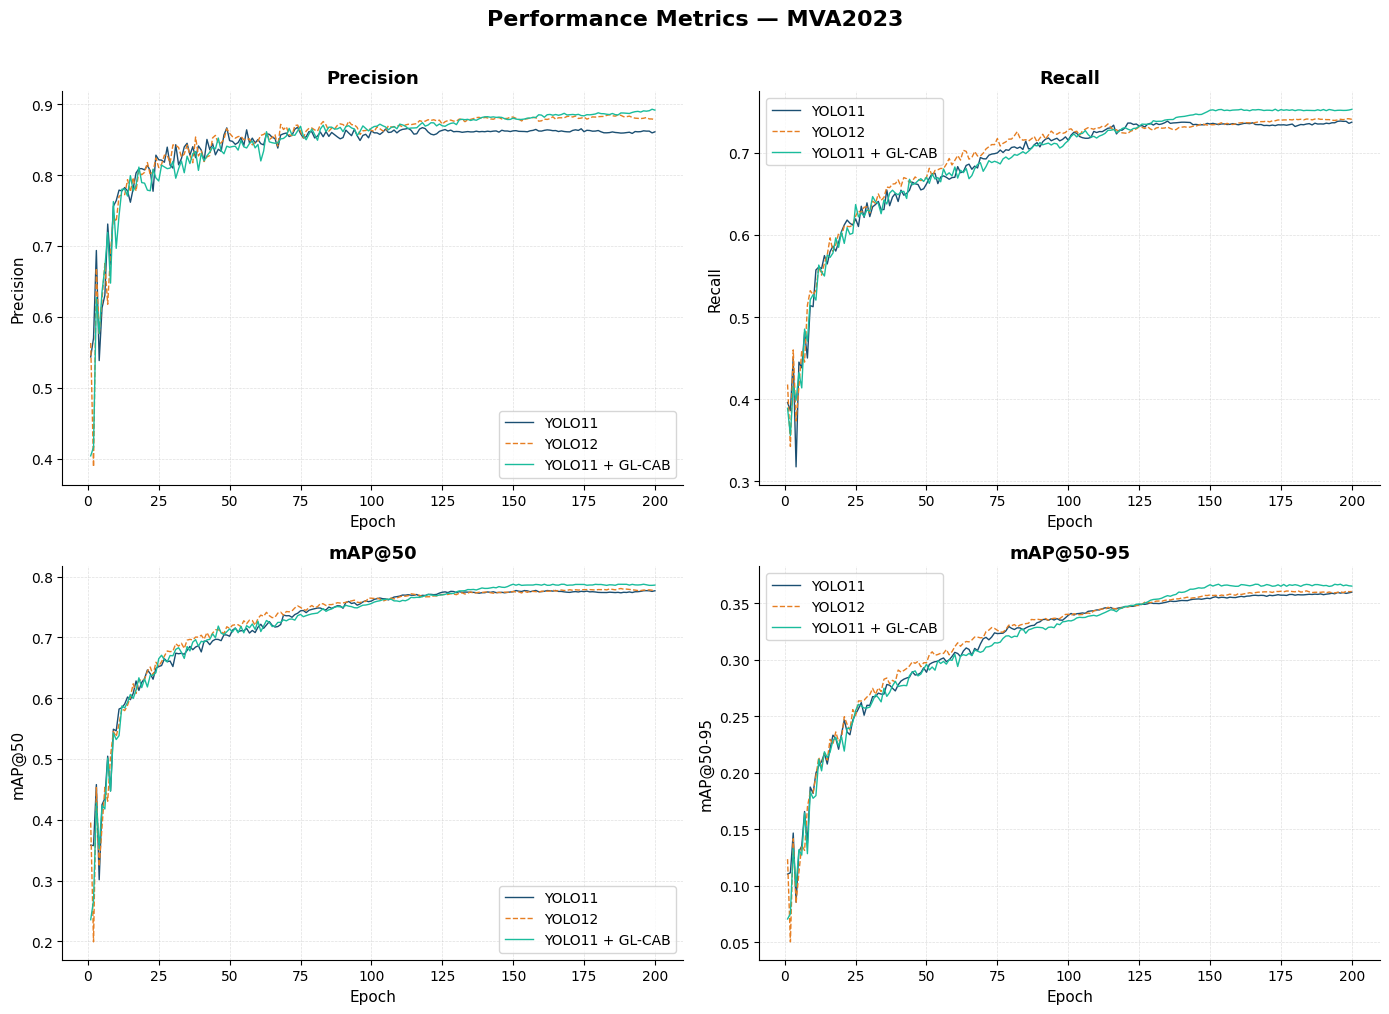

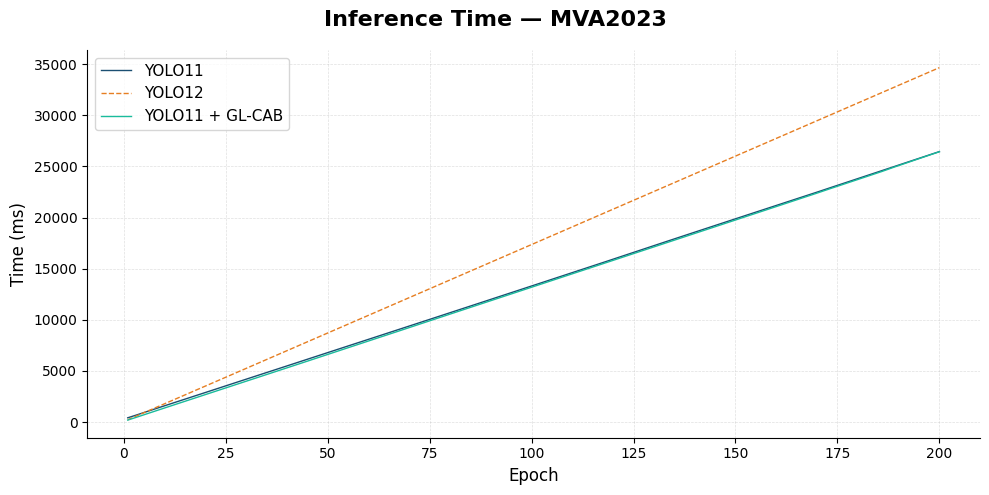

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os


# ─────────────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────────────

# Mapping dataset code → préfixe de fichier CSV
DATASET_FILES = {
    "vd":  ("vd11.csv",  "vd12.csv",  "vdGL.csv"),
    #"dt":  ("dt11.csv",  "dt12.csv",  "dtGL.csv"),
    "mva": ("mva11.csv", "mva12.csv", "mvaGL.csv"),
}

DATASET_LABELS = {
    "vd":  "VisDrone2019",
    #"dt":  "DOTA v1.5",
    "mva": "MVA2023",
}

MODEL_LABELS = ["YOLO11", "YOLO12", "YOLO11 + GL-CAB"]
MODEL_COLORS = ["#1B4F72", "#E67E22", "#1ABC9C"]   # bleu, orange, vert
MODEL_STYLES = ["-",       "--",      "-"]
MODEL_WIDTHS = [1,        1,       1]

# Métriques du panel 2×2
PERF_METRICS = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]
PERF_TITLES = ["Precision", "Recall", "mAP@50", "mAP@50-95"]

# Colonne temps
TIME_METRIC = "time"


# ─────────────────────────────────────────────────────────────────────────────
# Fonction principale
# ─────────────────────────────────────────────────────────────────────────────

def plot_comparison(dataset: str, data_dir: str = ".", save_dir: str = "."):
    """
    Génère deux figures de comparaison des modèles YOLO11 / YOLO12 / YOLO11+GL-CAB
    pour un dataset donné.

    Parameters
    ----------
    dataset  : str
        Code du dataset : "vd" (VisDrone), "dt" (DOTA), "mva" (MVA2023).
    data_dir : str
        Dossier contenant les fichiers CSV.
    save_dir : str
        Dossier où sauvegarder les figures produites.

    Returns
    -------
    fig_perf : matplotlib.figure.Figure
        Figure 2×2 des 4 métriques de performance.
    fig_time : matplotlib.figure.Figure
        Figure de la métrique temps.
    """

    if dataset not in DATASET_FILES:
        raise ValueError(
            f"Dataset '{dataset}' inconnu. Choisir parmi : {list(DATASET_FILES)}"
        )

    dataset_label = DATASET_LABELS[dataset]
    files = DATASET_FILES[dataset]

    # ── Chargement des données ──────────────────────────────────────────────
    dfs = []
    for fname in files:
        path = os.path.join(data_dir, fname)
        dfs.append(pd.read_csv(path))

    # ── Figure 1 : panel 2×2 des métriques de performance ──────────────────
    fig_perf, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig_perf.suptitle(
        f"Performance Metrics — {dataset_label}",
        fontsize=16, fontweight="bold", y=1.01
    )
    axes = axes.flatten()

    for ax, metric, title in zip(axes, PERF_METRICS, PERF_TITLES):
        for df, label, color, ls, lw in zip(
            dfs, MODEL_LABELS, MODEL_COLORS, MODEL_STYLES, MODEL_WIDTHS
        ):
            if metric in df.columns:
                epochs = df.iloc[:, 0]
                ax.plot(epochs, df[metric],
                        label=label, color=color,
                        linestyle=ls, linewidth=lw)
            else:
                print(f"[WARN] Colonne '{metric}' absente dans {label} — ignorée.")

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    path_perf = os.path.join(save_dir, f"perf_{dataset}.png")
    fig_perf.savefig(path_perf, dpi=150, bbox_inches="tight")
    print(f"[OK] Figure performance sauvegardée : {path_perf}")

    # ── Figure 2 : métrique temps ───────────────────────────────────────────
    fig_time, ax_time = plt.subplots(figsize=(10, 5))
    fig_time.suptitle(
        f"Inference Time — {dataset_label}",
        fontsize=16, fontweight="bold"
    )

    for df, label, color, ls, lw in zip(
        dfs, MODEL_LABELS, MODEL_COLORS, MODEL_STYLES, MODEL_WIDTHS
    ):
        if TIME_METRIC in df.columns:
            epochs = df.iloc[:, 0]
            ax_time.plot(epochs, df[TIME_METRIC],
                         label=label, color=color,
                         linestyle=ls, linewidth=lw)
        else:
            print(f"[WARN] Colonne '{TIME_METRIC}' absente dans {label} — ignorée.")

    ax_time.set_xlabel("Epoch", fontsize=12)
    ax_time.set_ylabel("Time (ms)", fontsize=12)
    ax_time.legend(fontsize=11)
    ax_time.grid(True, linestyle="--", alpha=0.4)
    ax_time.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    path_time = os.path.join(save_dir, f"time_{dataset}.png")
    fig_time.savefig(path_time, dpi=150, bbox_inches="tight")
    print(f"[OK] Figure temps sauvegardée : {path_time}")

    return fig_perf, fig_time


# ─────────────────────────────────────────────────────────────────────────────
# Exemple d'utilisation
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Générer les figures pour VisDrone
    fig_perf, fig_time = plot_comparison(
        dataset="mva",
        data_dir="r_paper",     # dossier contenant vd11.csv, vd12.csv, vdGL.csv
        save_dir="r_paper/figures",   # dossier de sortie
    )
    plt.show()

    # Décommenter pour les autres datasets :
    # plot_comparison("dt",  data_dir="rs600", save_dir="figures")
    # plot_comparison("mva", data_dir="rs600", save_dir="figures")

[OK] r_paper/figures/bar_perf_mva.png
[OK] r_paper/figures/bar_arch_mva.png
[OK] r_paper/figures/bar_perf_vd.png
[OK] r_paper/figures/bar_arch_vd.png


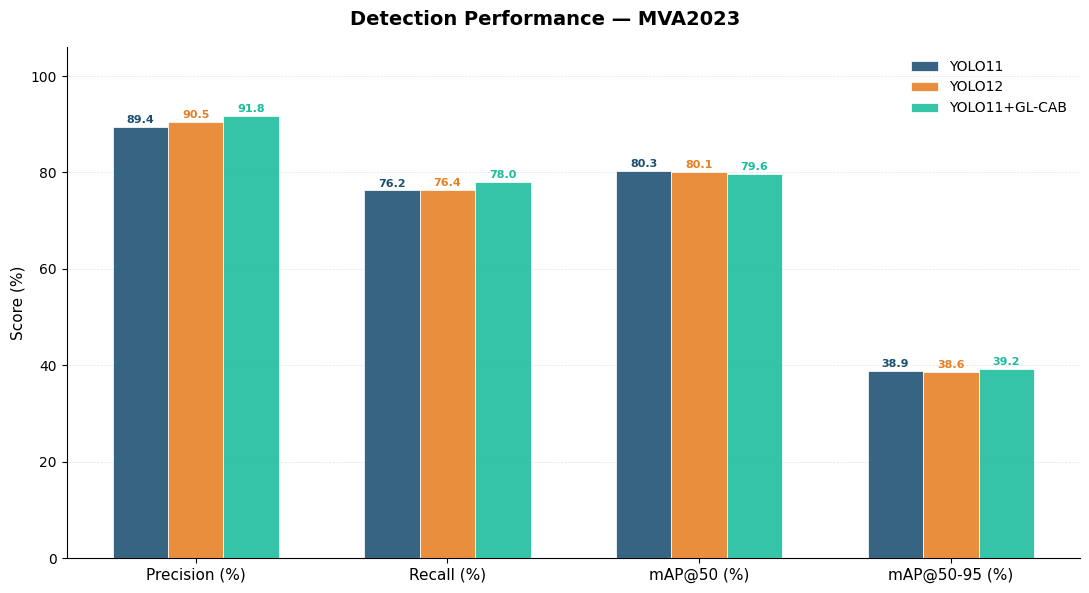

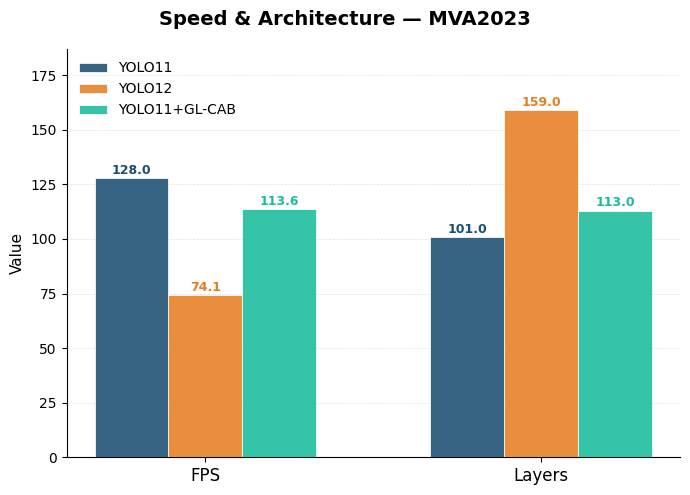

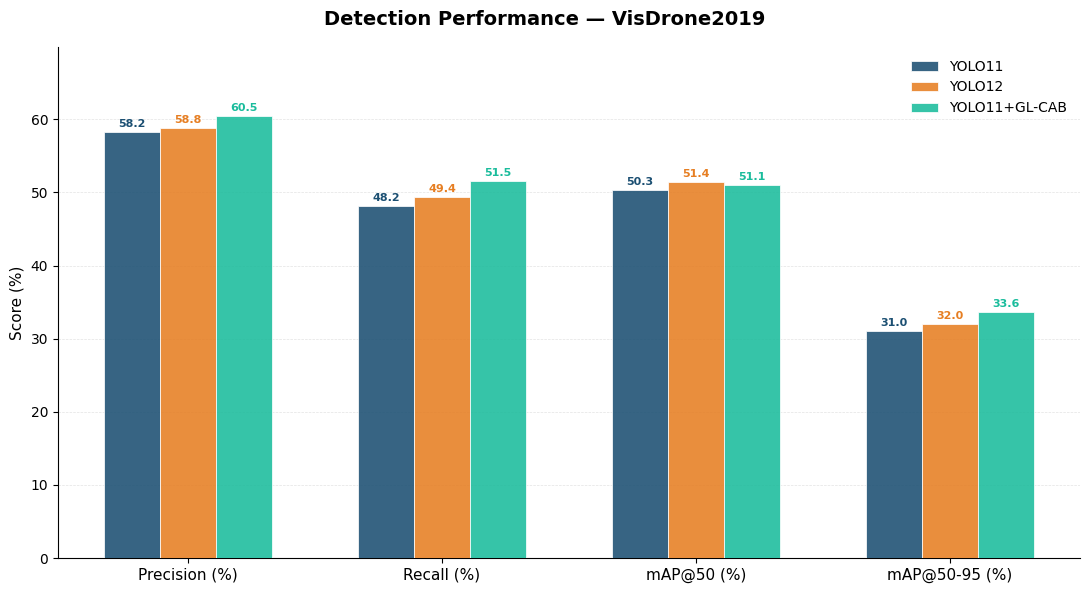

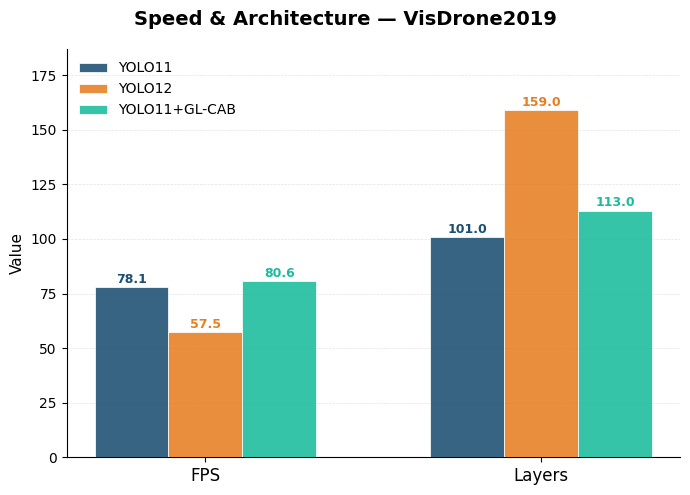

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

DATASET_LABELS = {"mva": "MVA2023", "vd": "VisDrone2019"}
MODEL_COLORS   = ["#1B4F72", "#E67E22", "#1ABC9C"]
BAR_ALPHA      = 0.88

def plot_barplots(csv_path: str, data_dir: str = ".", save_dir: str = "."):
    path = os.path.join(data_dir, csv_path)
    df   = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    stem          = os.path.splitext(csv_path)[0].lower()
    dataset_label = DATASET_LABELS.get(stem, stem.upper())
    models        = df["Model"].tolist()
    n             = len(models)
    colors        = MODEL_COLORS[:n]
    os.makedirs(save_dir, exist_ok=True)

    # ── Figure 1 : 4 métriques groupées ──────────────────────────────────────
    perf_metrics = ["Precision", "Recall", "mAP@50", "mAP@50-95"]
    perf_labels  = ["Precision (%)", "Recall (%)", "mAP@50 (%)", "mAP@50-95 (%)"]

    x         = np.arange(len(perf_metrics))   # 4 groupes
    bar_w     = 0.22
    offsets   = np.linspace(-(n-1)/2, (n-1)/2, n) * bar_w

    fig_perf, ax = plt.subplots(figsize=(11, 6))
    fig_perf.suptitle(f"Detection Performance — {dataset_label}",
                      fontsize=14, fontweight="bold")

    for i, (model, color, offset) in enumerate(zip(models, colors, offsets)):
        vals = [df.loc[df["Model"] == model, m].values[0] for m in perf_metrics]
        bars = ax.bar(x + offset, vals, width=bar_w,
                      color=color, alpha=BAR_ALPHA,
                      edgecolor="white", linewidth=0.6,
                      label=model, zorder=3)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.4,
                    f"{val:.1f}",
                    ha="center", va="bottom",
                    fontsize=8, fontweight="bold", color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(perf_labels, fontsize=11)
    ax.set_ylabel("Score (%)", fontsize=11)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
    ax.legend(fontsize=10, frameon=False)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    fig_perf.tight_layout()

    path_perf = os.path.join(save_dir, f"bar_perf_{stem}.png")
    fig_perf.savefig(path_perf, dpi=150, bbox_inches="tight")
    print(f"[OK] {path_perf}")

    # ── Figure 2 : FPS + Layers groupés ──────────────────────────────────────
    arch_metrics = ["FPS", "Layers"]
    arch_labels  = ["FPS", "Layers"]
    x2 = np.arange(len(arch_metrics))

    fig_arch, ax2 = plt.subplots(figsize=(7, 5))
    fig_arch.suptitle(f"Speed & Architecture — {dataset_label}",
                      fontsize=14, fontweight="bold")

    for i, (model, color, offset) in enumerate(zip(models, colors, offsets)):
        vals = [df.loc[df["Model"] == model, m].values[0] for m in arch_metrics]
        bars = ax2.bar(x2 + offset, vals, width=bar_w,
                       color=color, alpha=BAR_ALPHA,
                       edgecolor="white", linewidth=0.6,
                       label=model, zorder=3)
        for bar, val in zip(bars, vals):
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5,
                     f"{val:.1f}",
                     ha="center", va="bottom",
                     fontsize=9, fontweight="bold", color=color)

    ax2.set_xticks(x2)
    ax2.set_xticklabels(arch_labels, fontsize=12)
    ax2.set_ylabel("Value", fontsize=11)
    ax2.set_ylim(0, ax2.get_ylim()[1] * 1.12)
    ax2.legend(fontsize=10, frameon=False)
    ax2.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax2.spines[["top", "right"]].set_visible(False)
    fig_arch.tight_layout()

    path_arch = os.path.join(save_dir, f"bar_arch_{stem}.png")
    fig_arch.savefig(path_arch, dpi=150, bbox_inches="tight")
    print(f"[OK] {path_arch}")

    return fig_perf, fig_arch


for f in ["mva.csv", "vd.csv"]:
    plot_barplots(f, data_dir="r_paper", save_dir="r_paper/figures")
plt.show()